In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.plotting_styles import apply_global_style
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.config.paths import DATA_DIR
import os

In [16]:
full_dataset = load_dataset('FJ')
full_dataset = minmax_scale_per_sample(full_dataset)
train_set = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [15]:
eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [107]:
from sklearn.neighbors import NearestNeighbors

k = 15
neigh = NearestNeighbors(n_neighbors=k) 
neigh.fit(train_set)

neighborhood = []

for d in full_dataset:      
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]
 
MEAN = np.mean(avg_distances)

deviations = [abs(d-MEAN) for d in avg_distances]  
print(len(deviations))

620


In [108]:
neighborhood_outs = []

for d in eval_df['histogram']:      
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood_outs.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood_outs]

deviations_outs = [abs(d-MEAN) for d in avg_distances]  
print(len(deviations_outs))

10


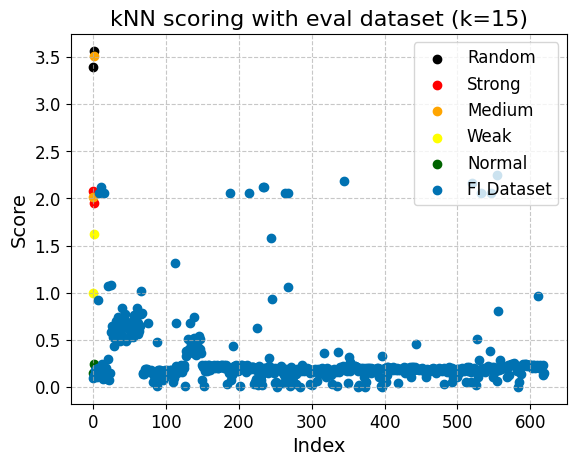

In [109]:
apply_global_style()

plt.title(f"kNN scoring with eval dataset (k={k})")
plt.xlabel("Index")
plt.ylabel("Score")
#plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(deviations_outs[:2])), deviations_outs[:2], color='black', label='Random')
plt.scatter(range(len(deviations_outs[2:4])), deviations_outs[2:4], color='red', label='Strong')
plt.scatter(range(len(deviations_outs[4:6])), deviations_outs[4:6], color='orange', label='Medium')
plt.scatter(range(len(deviations_outs[6:8])), deviations_outs[6:8], color='yellow', label='Weak')
plt.scatter(range(len(deviations_outs[8:])), deviations_outs[8:], color='darkgreen', label='Normal')
plt.scatter(range(len(deviations)), deviations, label='FI Dataset')
plt.legend()
plt.show()